# check init transform matrix:


In [2]:
import json
data_path = '/ssd/xiaxinyuan/dataset/3dgs_trajectory_vanilla/6F_v3/trajectory_0/data.json'
data = json.load(open(data_path, 'r'))


In [3]:
data

{'camera_intrinsic': [[232.80144458759122, 0.0, 160.0],
  [0.0, 234.45801582244215, 90.0],
  [0.0, 0.0, 1.0]],
 'camera_extrinsic': [[1.0, 0.0, 0.0, -0.0],
  [0.0, 0.5000000000000002, -0.8660254037844386, 0.0],
  [0.0, 0.8660254037844386, 0.5000000000000002, -0.3642202782518775],
  [0.0, 0.0, 0.0, 1.0]],
 'camera_trajectory': [[[0.9186117726714823,
    -0.19758062348656397,
    0.34221967846986523,
    -1.6552669747179003],
   [0.39516124697312777,
    0.45930588633574126,
    -0.7955411313489593,
    0.6938351169936088],
   [0.0, 0.8660254037844386, 0.5000000000000002, -0.3642202782518775],
   [0.0, 0.0, 0.0, 1.0]],
  [[0.9295209030354568,
    -0.18438471385946642,
    0.31936369254364505,
    -1.670129717304922],
   [0.36876942771893273,
    0.4647604515177285,
    -0.8049887153773574,
    0.729417573358192],
   [0.0, 0.8660254037844386, 0.5000000000000002, -0.3642202782518775],
   [0.0, 0.0, 0.0, 1.0]],
  [[0.9399877554769798,
    -0.17060408813489064,
    0.2954949486285891,
    -1

In [18]:
import numpy as np
def transform_matrix_to_pose(camera_transform_matrix):
    """将4x4变换矩阵转换为位置和朝向
    Args:
        camera_transform_matrix: [4, 4] numpy array
    Returns:
        position: [3,] xyz坐标
        orientation: [4,] 四元数 (x,y,z,w)
    """
    from scipy.spatial.transform import Rotation as R
    
    # 提取位置（前3个元素）
    position = camera_transform_matrix[:3, 3]
    
    # 提取旋转矩阵（左上3x3）并转换为四元数
    rotation_matrix = camera_transform_matrix[:3, :3]
    orientation = R.from_matrix(rotation_matrix).as_quat()  # 返回 [x,y,z,w] 格式的四元数
    
    return position, orientation
# save cam_position and cam_orientation as json file at ＇/ssd/xiaxinyuan/dataset/3dgs_trajectory_h1/＇

def get_trajectory(data_path):
    data = json.load(open(data_path, 'r'))
    cam_positions = []
    cam_orientations = []
    for i in range(len(data['camera_trajectory'])):
        cam_position, cam_orientation = transform_matrix_to_pose(np.array(data['camera_trajectory'][i]))
        # 如果和上一个cam_position的距离小于0.5，则不加入
        if len(cam_positions) > 0 and np.linalg.norm(cam_position - cam_positions[-1]) < 1.0:
            continue
        cam_positions.append(list(cam_position))
        cam_orientations.append(list(cam_orientation))
    total_len = np.linalg.norm(np.diff(cam_positions, axis=0), axis=1).sum()
    print(total_len)
    return cam_positions, cam_orientations

# data_dir = '/ssd/xiaxinyuan/dataset/3dgs_trajectory_vanilla/6F_v3/'
# import os
# # 遍历data_dir下所有文件夹
# for sub_dir in os.listdir(data_dir):
#     traj_path = os.path.join(data_dir, sub_dir, 'data.json')
#     cam_positions, cam_orientations = get_trajectory(traj_path)

test_file = '/ssd/xiaxinyuan/code/w61-grutopia/path_generation/test.json'
cam_positions, cam_orientations = get_trajectory(data_path)
episode_dict = {
    'camera_trajectory': cam_positions,
    'camera_init_orientation': cam_orientations[0]
}

with open(test_file, 'w') as f:
    json.dump(episode_dict, f)


6.096924380266811


In [9]:
episode_path = '/ssd/xiaxinyuan/code/w61-grutopia/path_generation/test.json'
data = json.load(open(episode_path, 'r'))
path = data['camera_trajectory']

In [ ]:
cam_positions = np.array(cam_positions)
cam_init_orientation = cam_orientations[0]

6.908448876675041


In [7]:
import open3d as o3d

# 遍历main_path下的所有pcd文件，并合并  
main_path = '/ssd/xiaxinyuan/code/w61-grutopia/thirdparty/landmark_isaacsim_interaction/rendered_imgs/sixth_floor/pcd/'
pcd_all = o3d.io.read_point_cloud(main_path + '200.pcd')
for i in range(300, 500, 100):
    pcd = o3d.io.read_point_cloud(main_path + f'{i}.pcd')
    pcd_all += pcd
o3d.io.write_point_cloud('/ssd/xiaxinyuan/code/w61-grutopia/thirdparty/landmark_isaacsim_interaction/rendered_imgs/sixth_floor/pcd/all.pcd', pcd_all)


True

-6.014729976654053 0.865789532661438
1.1254196166992188 9.221243858337402
-1.493769645690918 3.8317391872406006


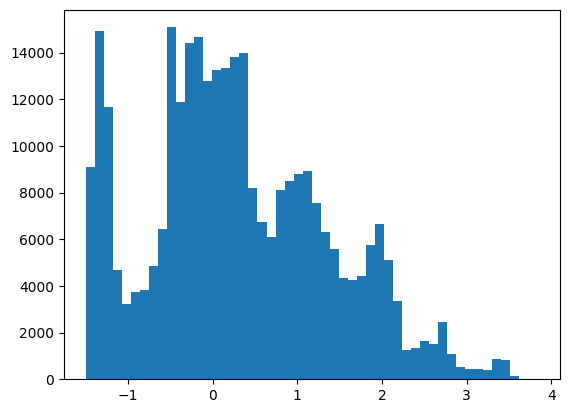

In [7]:
import open3d as o3d
import numpy as np
main_path = '/ssd/xiaxinyuan/code/w61-grutopia/thirdparty/landmark_isaacsim_interaction/rendered_imgs/sixth_floor/pcd/'
import matplotlib.pyplot as plt
# load pcd 100.pcd
pcd = o3d.io.read_point_cloud(main_path + '100.pcd')
# get the histgram of smallest z
x_values = np.array([point[0] for point in pcd.points])
y_values = np.array([point[1] for point in pcd.points])
z_values = np.array([point[2] for point in pcd.points])
print(x_values.min(), x_values.max())
print(y_values.min(), y_values.max())
print(z_values.min(), z_values.max())
# draw histgram
import matplotlib.pyplot as plt
_ = plt.hist(z_values, bins=50)


-7.893368244171143 0.8584812879562378
-2.059325695037842 5.682309627532959
-0.11914295703172684 2.694481611251831


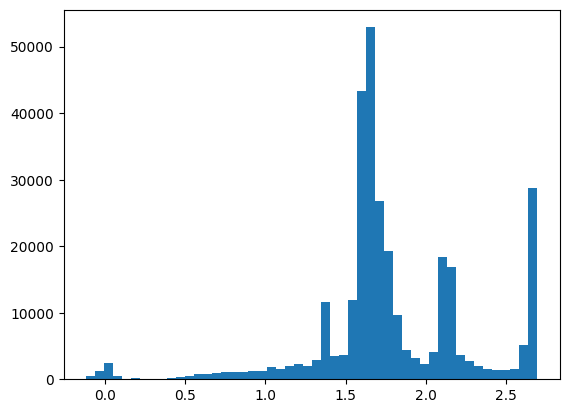

In [8]:
pcd = o3d.io.read_point_cloud(main_path + '200.pcd')
# get the histgram of smallest z
x_values = np.array([point[0] for point in pcd.points])
y_values = np.array([point[1] for point in pcd.points])
z_values = np.array([point[2] for point in pcd.points])
print(x_values.min(), x_values.max())
print(y_values.min(), y_values.max())
print(z_values.min(), z_values.max())
import matplotlib.pyplot as plt
_ = plt.hist(z_values, bins=50)


In [37]:
# sort z_values from small to large
z_values = np.sort(z_values)
# get the 10% of the smallest z
print(np.mean(z_values[:20]))

0.9940729379653931
